In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional
import julia
from functions import *
import matplotlib as mpl

In [27]:
@dataclass
class ResultsSimple:
    alphas: list = field(default_factory=list)
    xi0s: list = field(default_factory=list)
    xi1s: list = field(default_factory=list)
    rho0s: list = field(default_factory=list)
    rho1s: list = field(default_factory=list)
    rho2s: list = field(default_factory=list)

    J_alpha = None
    Jp_alpha = None
    xi0_alpha = None
    xi1_alpha = None
    rho0_alpha = None
    rho1_alpha = None
    rho2_alpha = None
    neg_weight_alpha = None
    lambda2_L0 = None
    lambda2_L0n = None

In [100]:
def compute_simple(G, N, alphas, seed=12):
    rng = np.random.default_rng(seed)
    res = ResultsSimple()

    A_0 = nx.to_numpy_array(G)

    # Symmetric part
    w_min = 0.5
    w_max = 1.5
    W = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            wundirect = rng.uniform(w_min, w_max)
            W[i, j] = wundirect
            W[j, i] = wundirect

    # Antisymmetric part
    Delta = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            direction = rng.choice([-1, 1])
            wdirect = rng.uniform(w_min, w_max)
            Delta[i, j] = direction * wdirect
            Delta[j, i] = -direction * wdirect

    # Topology
    d_0 = A_0.sum(axis=1)
    L_0 = np.diag(d_0) - A_0
    L_0_norm = np.diag(d_0**(-0.5)) @ L_0 @ np.diag(d_0**(-0.5))
    res.lambda2_L0n = np.real(scipy.linalg.eigh(L_0_norm, eigvals_only=True, subset_by_index=[1, 1]))[0]
    res.lambda2_L0 = np.real(scipy.linalg.eigh(L_0, eigvals_only=True, subset_by_index=[1, 1]))[0]

    # # Projector
    # e = np.ones((N, 1))
    # Proj = np.eye(N) - (1/N) * (e @ e.T)

    res.alphas.append(0.0)
    res.xi0s.append(0.0)
    res.xi1s.append(0.0)
    res.rho0s.append(0.0)
    res.rho1s.append(0.0)
    res.rho2s.append(0.0)
    #for alpha in alphas:
    for i in range(1, len(alphas)):
        alpha_prev = alphas[i - 1]
        alpha = alphas[i]
        res.alphas.append(alpha)

        # Laplacian
        A = W + alpha * Delta
        A[~A_0.astype(bool)] = 0
        D = np.diag(A.sum(axis=1))
        L = D - A

        # Edge weights
        if res.neg_weight_alpha == None and (A < 0).any():
            res.neg_weight_alpha = alpha_prev
        dout_din = (A.sum(axis=1) - A.sum(axis=0))

        # Jacobian max eigenvalue
        eigvals_J = scipy.linalg.eigvals(-L)
        lambda_J = np.max(np.real(eigvals_J))
        #lambda_J, _ = scipy.sparse.linalg.eigs(-L, k=1, which='LR')
        #lambda_J = np.real(lambda_J[0])
        if res.J_alpha == None and lambda_J > 1e-10: 
            res.J_alpha = alpha_prev

        # # Projected Jacobian
        # L_perp = Proj @ L
        # #L_perp = reduce(L)
        # H_perp = 0.5 * (L_perp + L_perp.T)
        # eigvals_Jp = scipy.linalg.eigvalsh(-H_perp)
        # lambda_Jp = np.max(eigvals_Jp)
        # #lambda_Jp, _ = scipy.sparse.linalg.eigsh(-H_perp, k=1, which='LA')
        # #lambda_Jp = np.real(lambda_Jp[0])
        # if res.Jp_alpha == None and lambda_Jp > 1e-10: 
        #     res.Jp_alpha = alpha_prev

        # Undirected part
        A_plus = 0.5 * (A + A.T)
        L_plus = np.diag(A_plus.sum(axis=1)) - A_plus
        L_plus_r = reduce(L_plus)

        # Superdirected part
        A_minus = 0.5 * (A - A.T)
        L_minus = np.diag(A_minus.sum(axis=1)) - A_minus
        L_minus_r = reduce(L_minus)

        # xi0
        xi0 = -compute_xi0(L_plus_r, L_minus_r)
        res.xi0s.append(xi0)
        if res.xi0_alpha == None and xi0 >= 1: 
            res.xi0_alpha = alpha_prev

        # xi1 
        A_plus_min = np.min(A_plus[A_plus != 0])
        xi1 = -min(0.5*dout_din) / (A_plus_min * res.lambda2_L0)
        res.xi1s.append(xi1)
        if res.xi1_alpha == None and xi1 >= 1: 
            res.xi1_alpha = alpha_prev

        # rho0
        rho0 = compute_rho0(L_plus_r, L_minus_r)
        res.rho0s.append(rho0)
        if res.rho0_alpha == None and rho0 >= 1: 
            res.rho0_alpha = alpha_prev

        # rho1
        rho1 = compute_rho1(A_plus, A_minus, res.lambda2_L0)
        res.rho1s.append(rho1)
        if res.rho1_alpha == None and rho1 >= 1: 
            res.rho1_alpha = alpha_prev

        # rho2
        rho2 = compute_rho2(A_plus, A_minus, A_0, res.lambda2_L0n)
        res.rho2s.append(rho2)
        if res.rho2_alpha == None and rho2 >= 1: 
            res.rho2_alpha = alpha_prev

        if res.J_alpha is not None:
            break

    return res

In [115]:
def plot_simple_two(r1, r2):

    mpl.rcdefaults()
    plt.style.use("default")
    mpl.rcParams.update({
        "text.usetex": False,  
        "font.family": "serif",
        "mathtext.fontset": "cm",
    })

    fig, ax = plt.subplots(1, 2, figsize=(7, 2.6), dpi=300)

    for a, r in [(ax[0], r1), (ax[1], r2)]:

        a.plot(r.alphas, r.xi0s, color="red", label = r"$-\xi$")
        if r.xi0_alpha is not None:
            a.axvline(r.xi0_alpha, ls="--", c="red")

        a.plot(r.alphas, r.xi1s, color="orange", label = r"$-\xi_1$")
        if r.xi1_alpha is not None:
            a.axvline(r.xi1_alpha, ls="--", c="orange")

        a.plot(r.alphas, r.rho0s, color="blue", label = r"$\rho$")
        if r.rho0_alpha is not None:
            a.axvline(r.rho0_alpha, ls="--", c="blue")

        a.plot(r.alphas, r.rho1s, color="green", label = r"$\rho_1$")
        if r.rho1_alpha is not None:
            a.axvline(r.rho1_alpha, ls="--", c="green")

        a.plot(r.alphas, r.rho2s, color="purple", label = r"$\rho_2$")
        if r.rho2_alpha is not None:
            a.axvline(r.rho2_alpha, ls="--", c="purple")

        if r.J_alpha is not None:
            a.axvline(r.J_alpha, ls="--", c="k")
            
        if r.neg_weight_alpha is not None:
            a.axvline(r.neg_weight_alpha, ls="--", c="0.5")

        a.axhline(1, c="k", linewidth=1)

        a.grid(True, alpha=0.3)
        a.set_xlabel(r"$\alpha$")
        ymax = 2
        a.set_ylim(-ymax/10, ymax)

    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.1), handlelength=1.5)

    fig.tight_layout()
    fig.savefig("simple_Laplacian.pdf", bbox_inches="tight") 
    plt.show()

In [117]:
# ER graph
N = 200
p = 0.5
G = nx.erdos_renyi_graph(N, p, seed=12345)

alphas_simple_ER = np.linspace(0, 8.0, 500)

res_simple_ER = compute_simple(G, N, alphas_simple_ER, seed=12)

In [118]:
# WS graph
N = 200
k = 4
p = 0.1
G = nx.watts_strogatz_graph(N, k, p, seed=1234567)

alphas_simple_WS = np.linspace(0, 1, 500) 

res_simple_WS = compute_simple(G, N, alphas_simple_WS, seed=12)

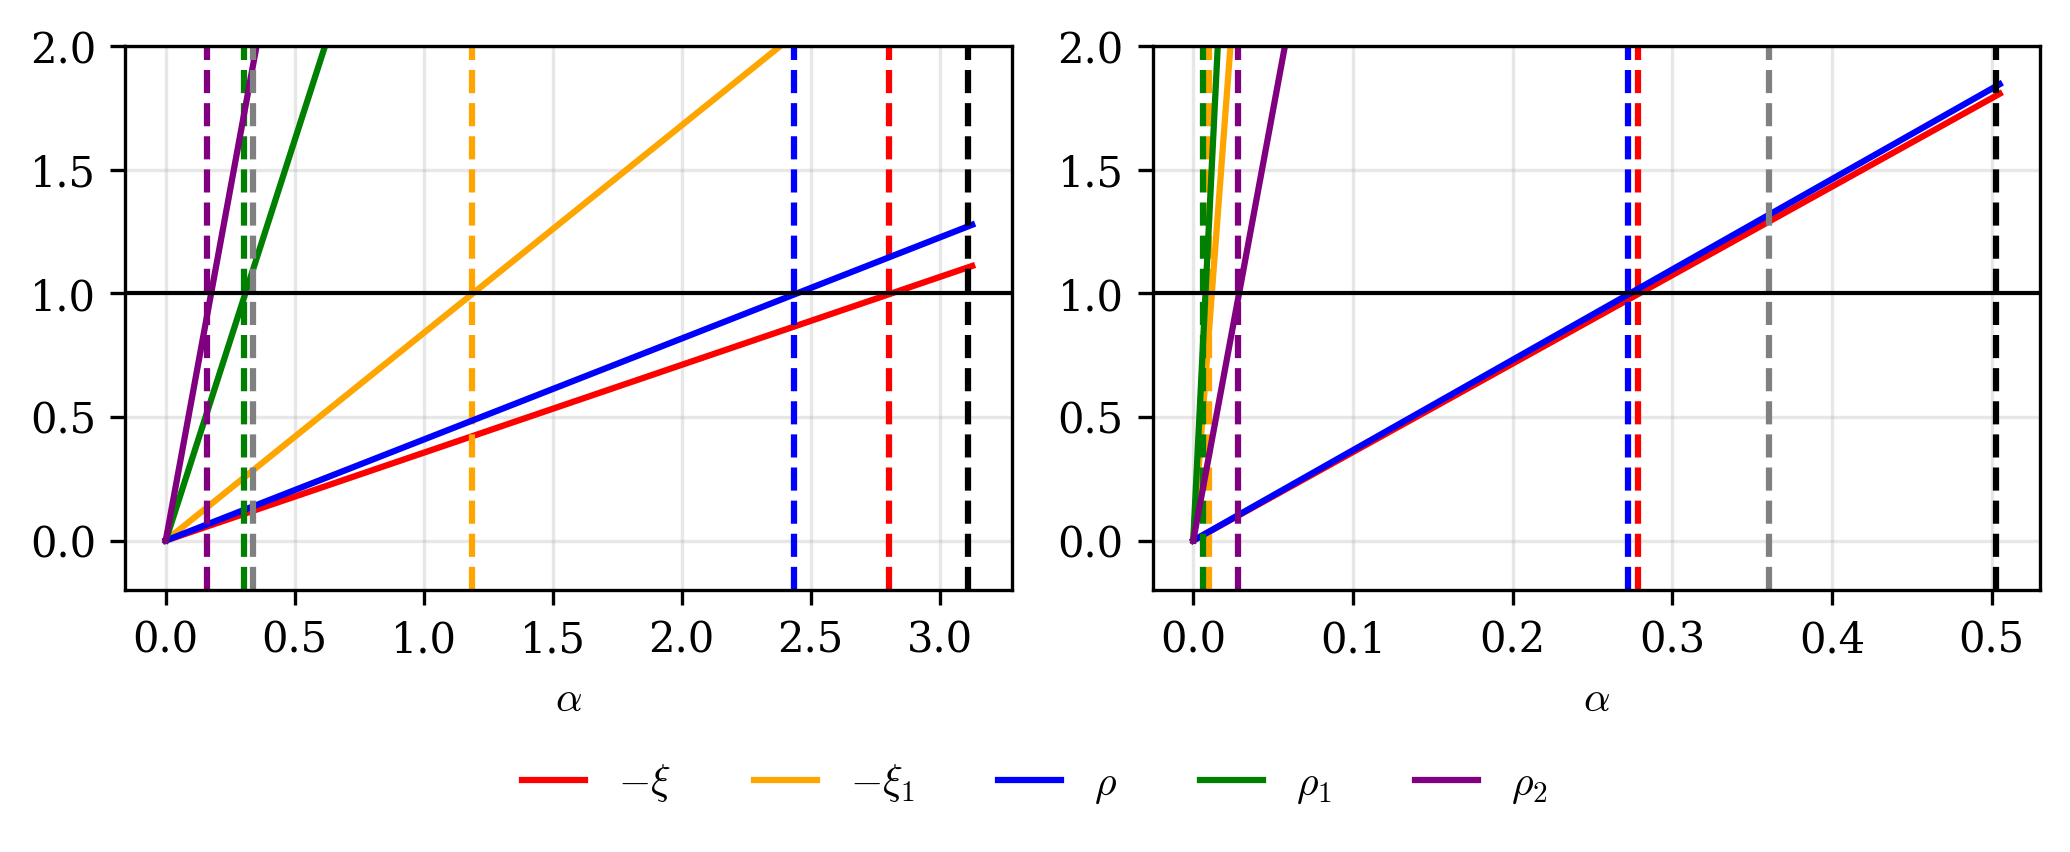

In [120]:
plot_simple_two(res_simple_ER, res_simple_WS)